# Direct Cellpose Segmentation

Uses `lsp.cellpose()` directly without Suite2p preprocessing.
Includes zoomed views to evaluate small cell detection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle
from matplotlib.colors import hsv_to_rgb

import mbo_utilities as mbo
import lbm_suite2p_python as lsp

# dark theme
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['savefig.facecolor'] = 'black'

In [2]:
# data paths
RAW_PATH = Path(r"\\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq1")
OUTPUT_DIR = Path(r"D:/cj/2025-12-11/cellpose_direct")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input: {RAW_PATH}")
print(f"Output: {OUTPUT_DIR}")

Input: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq1
Output: D:\cj\2025-12-11\cellpose_direct


In [3]:
# check data shape
arr = mbo.imread(RAW_PATH, fix_phase=True, use_fft=True)
print(f"Shape: {arr.shape}")

Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

Shape: (970, 2, 772, 735)


---
## Run lsp.cellpose()

In [4]:
# cellpose parameters
DIAMETER = 4
CELLPROB_THRESHOLD = -6.0
FLOW_THRESHOLD = 0.0
PROJECTION = "max"
MODEL_TYPE = "cpsam"  # cp-sam model
MIN_SIZE = 2
MAX_SIZE_UM = 35  # max cell diameter in microns (cortical neurons < 35um)

# run cellpose directly - pass path, use planes param
results = lsp.cellpose(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=None,  # None = All z-planes
    projection=PROJECTION,
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_THRESHOLD,
    flow_threshold=FLOW_THRESHOLD,
    model_type=MODEL_TYPE,
    min_size=MIN_SIZE,
    max_size_um=MAX_SIZE_UM,  # removes masks > 35um diameter if pixel size available
    reader_kwargs={"fix_phase": True, "use_fft": True},
)

print(f"\nResults saved to: {OUTPUT_DIR}")

Cellpose Segmentation
Loading input data...
  Input: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq1


Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

model_type argument is not used in v4.0.1+. Ignoring this argument...


  Loaded as: MboRawArray

Dataset info:
  Shape: (970, 2, 772, 735)
  Frames: 970
  Planes: 2
  Data type: 4D volumetric

Processing plan:
  Planes: [1, 2]
  Projection: max
  Output: D:\cj\2025-12-11\cellpose_direct

GPU: enabled

Loading Cellpose model (cpsam)...
  Model loaded in 1.65s

Processing plane 1/2
  Loading existing results...
  Found 629 existing ROIs

Processing plane 2/2
  Loading existing results...
  Found 581 existing ROIs

Summary
  Total ROIs: 1210
  Total time: 1.8s
  Output: D:\cj\2025-12-11\cellpose_direct

Results saved to: D:\cj\2025-12-11\cellpose_direct


In [5]:
# load results for first plane (file uses 0-indexed plane)
PLANE_IDX = 0  # 0-indexed for loading
cp_results = lsp.load_cellpose_results(OUTPUT_DIR, plane_idx=PLANE_IDX)
masks = cp_results["masks"]
proj = cp_results["projection"]

n_cells = int(masks.max())
print(f"Plane {PLANE_IDX}: Detected {n_cells} cells")
print(f"Projection shape: {proj.shape}")
print(f"Masks shape: {masks.shape}")

Plane 0: Detected 629 cells
Projection shape: (772, 735)
Masks shape: (772, 735)


---
## Visualization Helpers

In [6]:
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def mask_overlay(img, masks, alpha=0.4):
    """overlay colored masks on grayscale image"""
    img_norm = normalize99(img)
    rgb = np.stack([img_norm]*3, axis=-1)
    if masks.max() > 0:
        n = masks.max()
        np.random.seed(42)
        colors = np.zeros((n+1, 3))
        for i in range(1, n+1):
            colors[i] = hsv_to_rgb([np.random.rand(), 0.8, 0.9])
        mask_rgb = colors[masks]
        mask_area = masks > 0
        rgb[mask_area] = (1-alpha)*rgb[mask_area] + alpha*mask_rgb[mask_area]
    return np.clip(rgb, 0, 1)

def count_cells_in_region(masks, y0, y1, x0, x1):
    """count unique cells in region"""
    region = masks[y0:y1, x0:x1]
    return len(np.unique(region)) - (1 if 0 in region else 0)

---
## Full FOV with Zoom Boxes

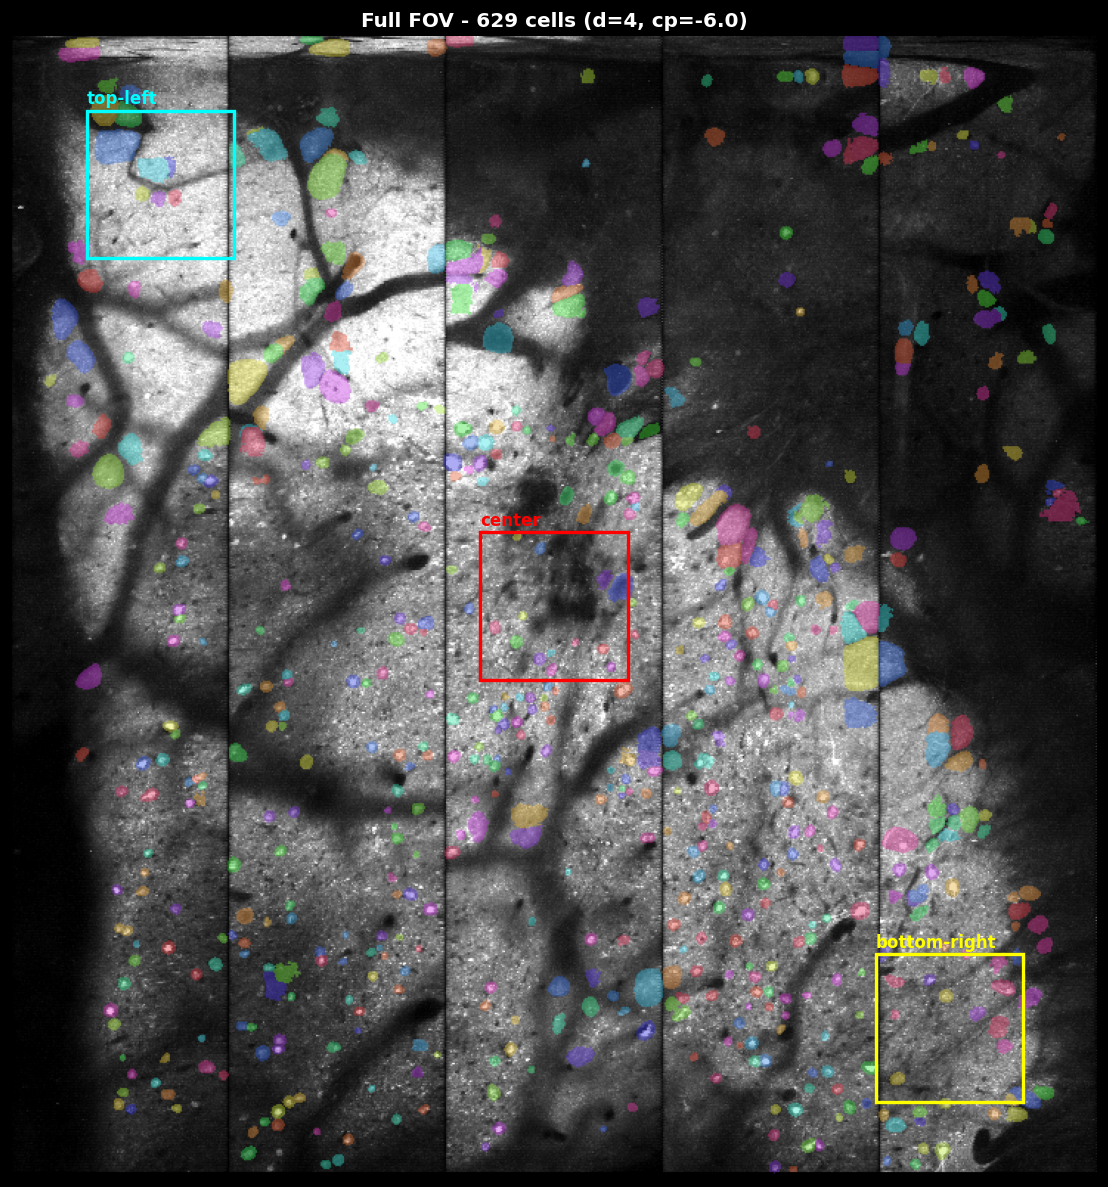

In [7]:
Ly, Lx = proj.shape
cy, cx = Ly // 2, Lx // 2

# define zoom regions (different areas to check small cells)
ZOOM_SIZE = 100
zoom_regions = {
    "center": (cy - ZOOM_SIZE//2, cy + ZOOM_SIZE//2, cx - ZOOM_SIZE//2, cx + ZOOM_SIZE//2),
    "top-left": (50, 50 + ZOOM_SIZE, 50, 50 + ZOOM_SIZE),
    "bottom-right": (Ly - 50 - ZOOM_SIZE, Ly - 50, Lx - 50 - ZOOM_SIZE, Lx - 50),
}

# colors for zoom boxes
box_colors = {'center': 'red', 'top-left': 'cyan', 'bottom-right': 'yellow'}

# plot full FOV with zoom boxes
overlay = mask_overlay(proj, masks)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(overlay)
ax.set_title(f"Full FOV - {n_cells} cells (d={DIAMETER}, cp={CELLPROB_THRESHOLD})", fontweight='bold')
ax.axis('off')

# add zoom boxes
for name, (y0, y1, x0, x1) in zoom_regions.items():
    rect = Rectangle((x0, y0), x1-x0, y1-y0,
                     linewidth=2, edgecolor=box_colors[name], facecolor='none')
    ax.add_patch(rect)
    ax.text(x0, y0-5, name, color=box_colors[name], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Zoomed Views - Evaluate Small Cell Detection

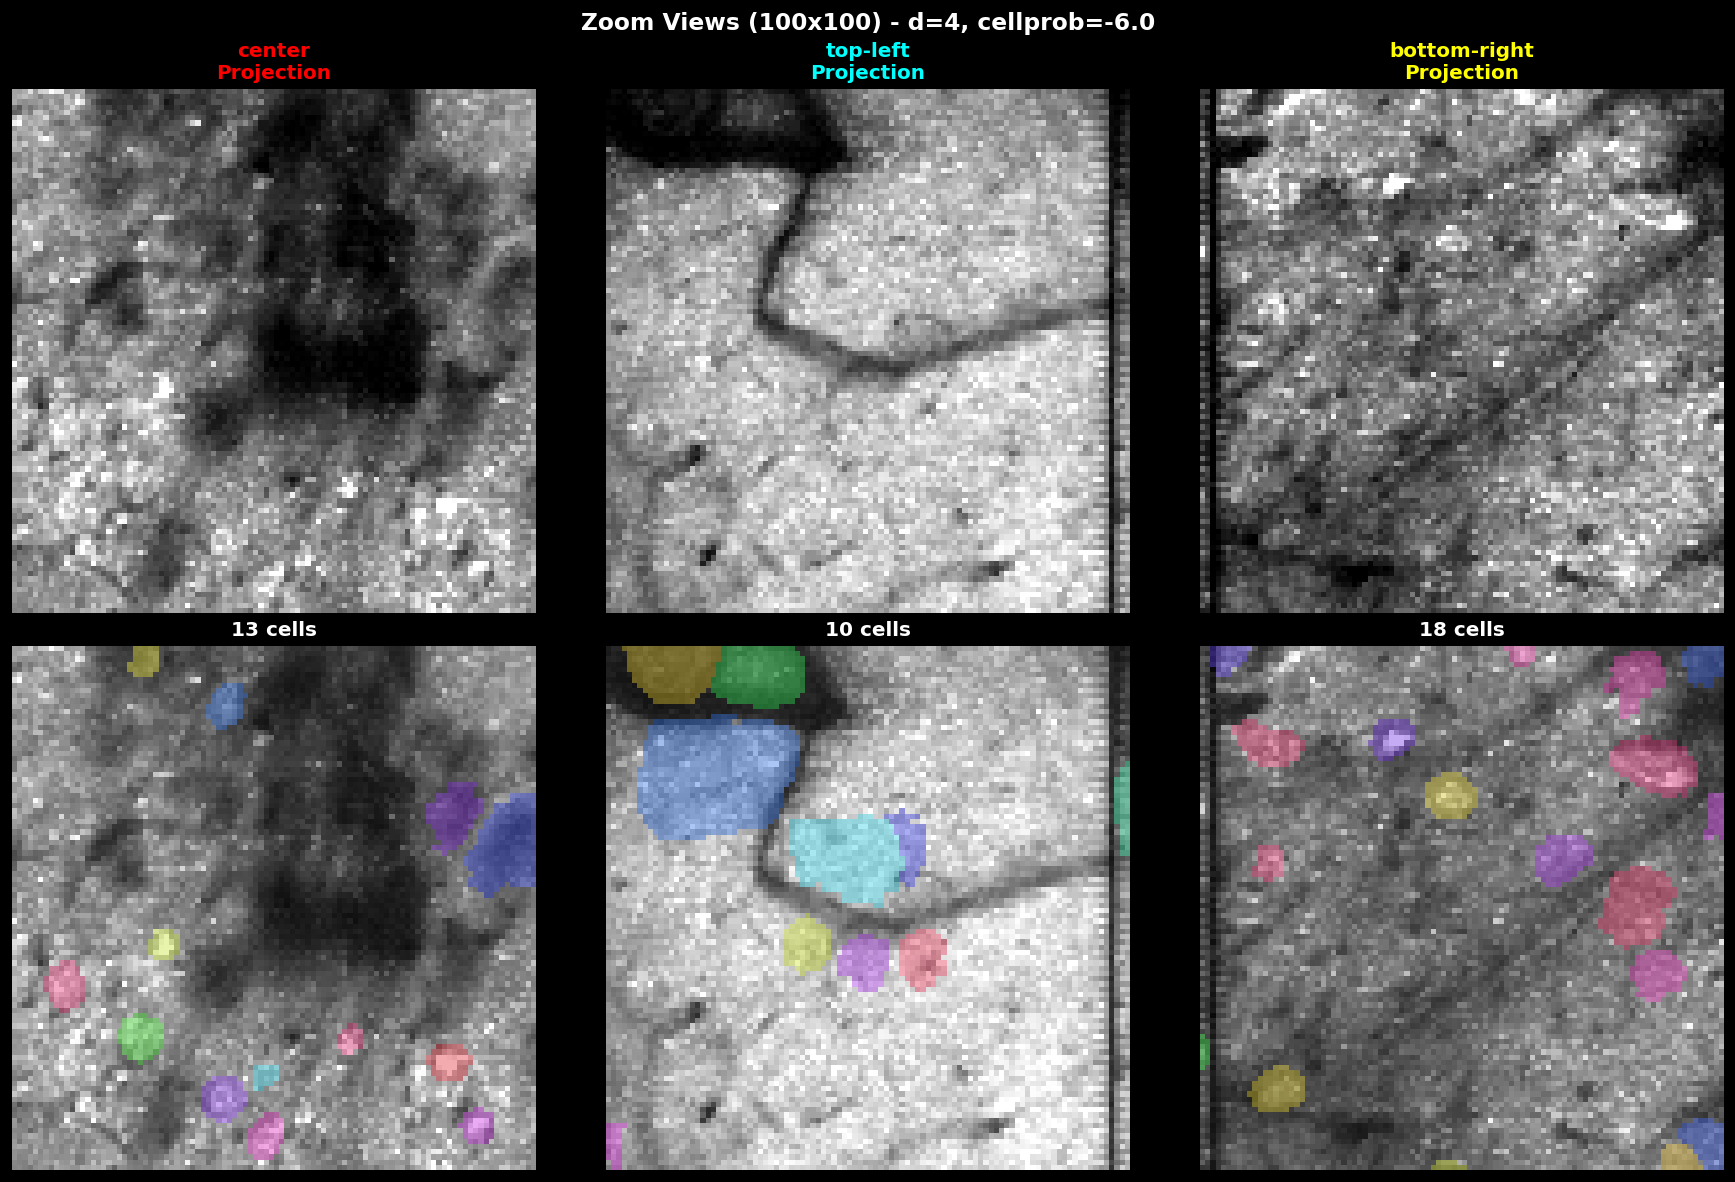

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (name, (y0, y1, x0, x1)) in enumerate(zoom_regions.items()):
    n_region = count_cells_in_region(masks, y0, y1, x0, x1)

    # top row: projection only
    axes[0, i].imshow(normalize99(proj[y0:y1, x0:x1]), cmap='gray')
    axes[0, i].set_title(f"{name}\nProjection", fontweight='bold', color=box_colors[name])
    axes[0, i].axis('off')

    # bottom row: with masks
    axes[1, i].imshow(overlay[y0:y1, x0:x1])
    axes[1, i].set_title(f"{n_region} cells", fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle(f"Zoom Views ({ZOOM_SIZE}x{ZOOM_SIZE}) - d={DIAMETER}, cellprob={CELLPROB_THRESHOLD}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Smaller Zoom (50x50) for Fine Detail

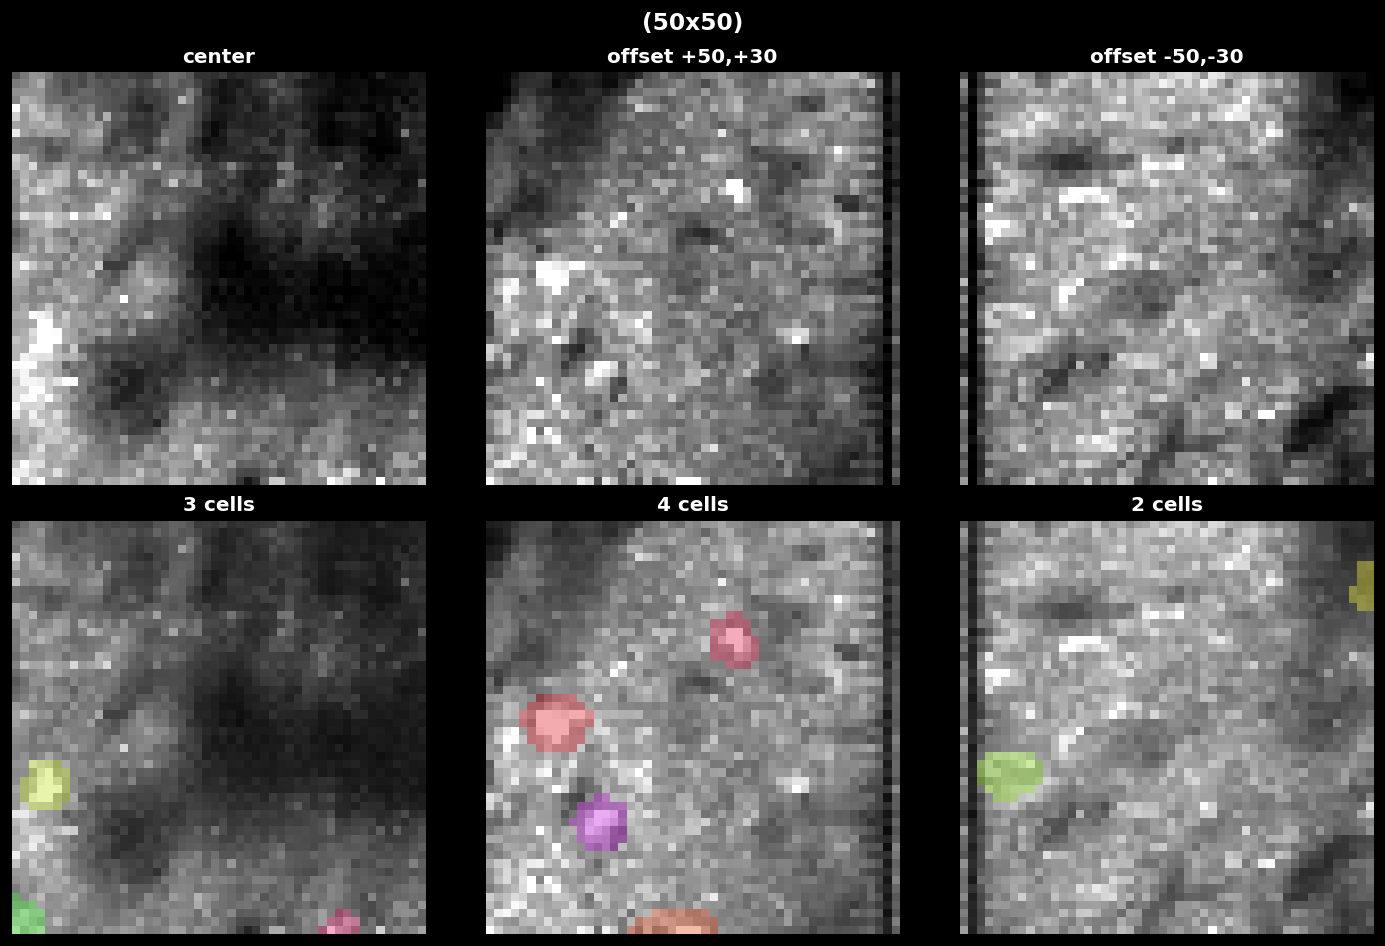

In [14]:
# smaller zoom regions for fine detail
SMALL_ZOOM = 50
small_zooms = {
    "center": (cy - SMALL_ZOOM//2, cy + SMALL_ZOOM//2, cx - SMALL_ZOOM//2, cx + SMALL_ZOOM//2),
    "offset +50,+30": (cy + 30 - SMALL_ZOOM//2, cy + 30 + SMALL_ZOOM//2,
                       cx + 50 - SMALL_ZOOM//2, cx + 50 + SMALL_ZOOM//2),
    "offset -50,-30": (cy - 30 - SMALL_ZOOM//2, cy - 30 + SMALL_ZOOM//2,
                       cx - 50 - SMALL_ZOOM//2, cx - 50 + SMALL_ZOOM//2),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, (name, (y0, y1, x0, x1)) in enumerate(small_zooms.items()):
    n_region = count_cells_in_region(masks, y0, y1, x0, x1)

    # top row: projection only
    axes[0, i].imshow(normalize99(proj[y0:y1, x0:x1]), cmap='gray')
    axes[0, i].set_title(f"{name}", fontweight='bold')
    axes[0, i].axis('off')

    # bottom row: with masks
    axes[1, i].imshow(overlay[y0:y1, x0:x1])
    axes[1, i].set_title(f"{n_region} cells", fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle(f"({SMALL_ZOOM}x{SMALL_ZOOM})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Compare Different Parameters

In [15]:
# compare different diameter/cellprob combinations
from cellpose import models, core

model = models.CellposeModel(model_type='cpsam', gpu=core.use_gpu())
proj_norm = normalize99(proj)

param_grid = [
    {"diameter": 3, "cellprob_threshold": -6},
    {"diameter": 4, "cellprob_threshold": -6},
    {"diameter": 6, "cellprob_threshold": -6},
    {"diameter": 4, "cellprob_threshold": -4},
]

param_results = {}
for params in param_grid:
    masks_i, _, _ = model.eval(
        proj_norm,
        diameter=params["diameter"],
        cellprob_threshold=params["cellprob_threshold"],
        flow_threshold=0.0,
    )
    key = f"d={params['diameter']}, cp={params['cellprob_threshold']}"
    param_results[key] = masks_i
    print(f"{key}: {masks_i.max()} cells")

model_type argument is not used in v4.0.1+. Ignoring this argument...


d=3, cp=-6: 625 cells
d=4, cp=-6: 633 cells
d=6, cp=-6: 754 cells
d=4, cp=-4: 633 cells


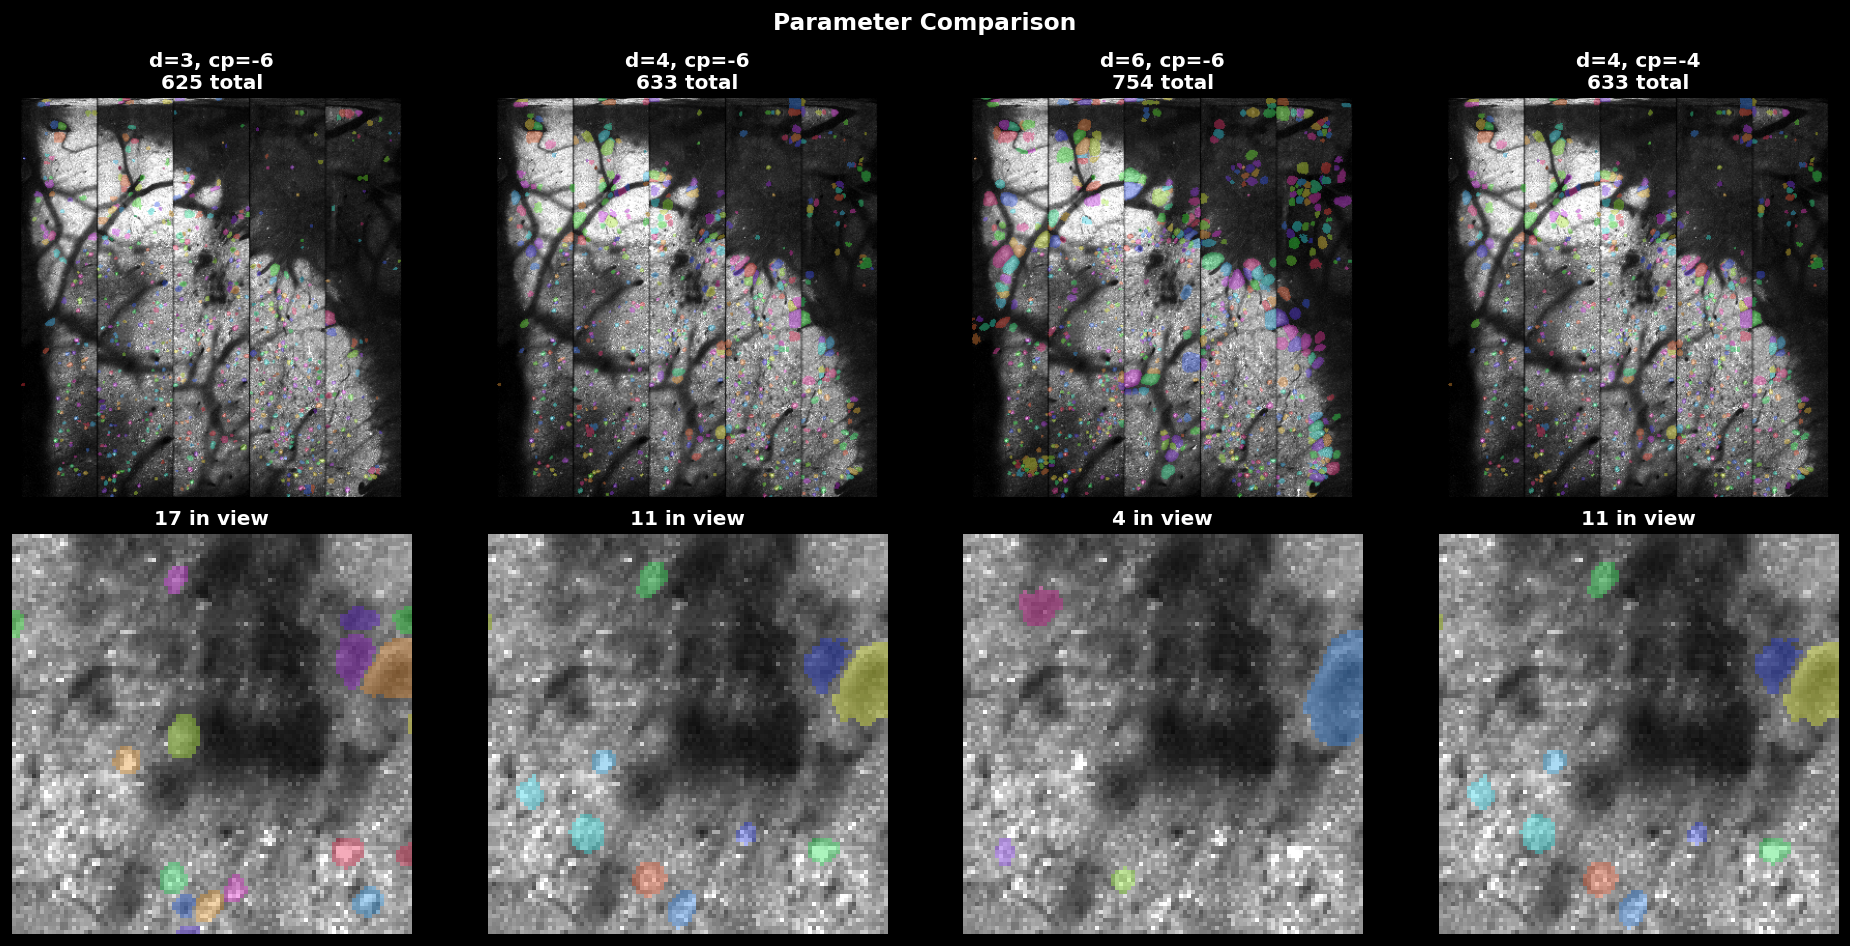

In [11]:
# compare in zoomed view
y0, y1, x0, x1 = zoom_regions['center']

fig, axes = plt.subplots(2, len(param_results), figsize=(16, 8))

for i, (key, masks_i) in enumerate(param_results.items()):
    overlay_i = mask_overlay(proj, masks_i)
    n_total = int(masks_i.max())
    n_region = count_cells_in_region(masks_i, y0, y1, x0, x1)

    # full FOV (scaled down)
    axes[0, i].imshow(overlay_i[::2, ::2])  # downsample for display
    axes[0, i].set_title(f"{key}\n{n_total} total", fontweight='bold')
    axes[0, i].axis('off')

    # zoomed
    axes[1, i].imshow(overlay_i[y0:y1, x0:x1])
    axes[1, i].set_title(f"{n_region} in view", fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Parameter Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell Size Distribution

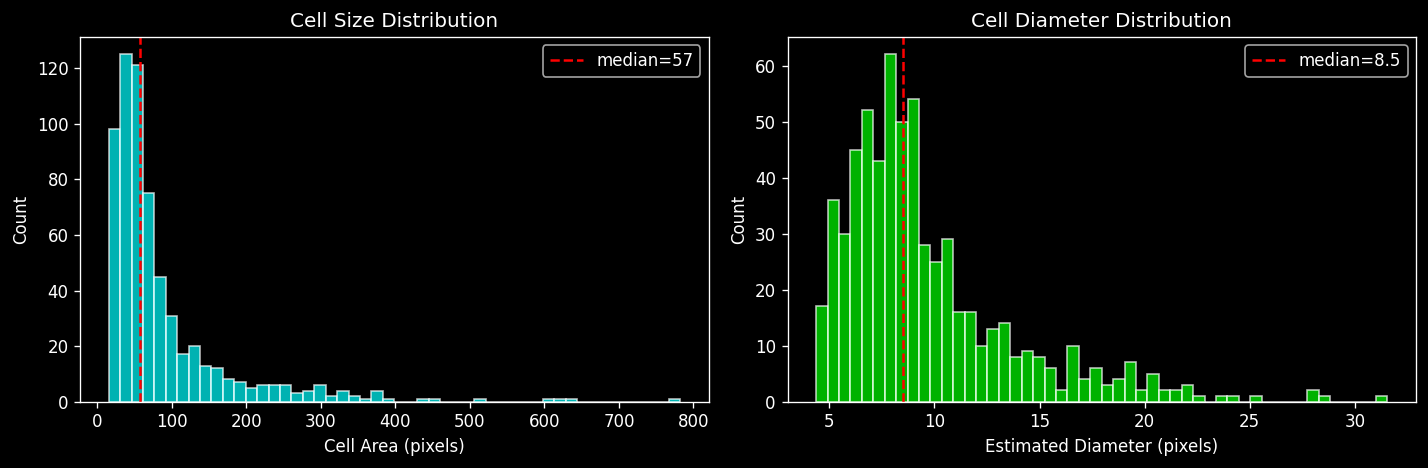

Cell count: 629
Area - min: 15, max: 782, median: 57
Diameter - min: 4.4, max: 31.6, median: 8.5


In [12]:
# compute cell sizes from masks
cell_ids, cell_sizes = np.unique(masks[masks > 0], return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
axes[0].hist(cell_sizes, bins=50, color='cyan', edgecolor='white', alpha=0.7)
axes[0].axvline(np.median(cell_sizes), color='red', linestyle='--', label=f'median={np.median(cell_sizes):.0f}')
axes[0].set_xlabel('Cell Area (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Cell Size Distribution')
axes[0].legend()

# diameter estimate (assuming circular)
diameters = 2 * np.sqrt(cell_sizes / np.pi)
axes[1].hist(diameters, bins=50, color='lime', edgecolor='white', alpha=0.7)
axes[1].axvline(np.median(diameters), color='red', linestyle='--', label=f'median={np.median(diameters):.1f}')
axes[1].set_xlabel('Estimated Diameter (pixels)')
axes[1].set_ylabel('Count')
axes[1].set_title('Cell Diameter Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Cell count: {len(cell_sizes)}")
print(f"Area - min: {cell_sizes.min()}, max: {cell_sizes.max()}, median: {np.median(cell_sizes):.0f}")
print(f"Diameter - min: {diameters.min():.1f}, max: {diameters.max():.1f}, median: {np.median(diameters):.1f}")

---
## Summary

In [13]:
print("=" * 50)
print("Cellpose Direct Results")
print("=" * 50)
print(f"Input: {RAW_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"")
print(f"Parameters:")
print(f"  model_type: {MODEL_TYPE}")
print(f"  projection: {PROJECTION}")
print(f"  diameter: {DIAMETER}")
print(f"  cellprob_threshold: {CELLPROB_THRESHOLD}")
print(f"  flow_threshold: {FLOW_THRESHOLD}")
print(f"  min_size: {MIN_SIZE}")
print(f"  max_size_um: {MAX_SIZE_UM}")
print(f"")
print(f"Results (Plane {PLANE_IDX}):")
print(f"  Total cells: {n_cells}")
print(f"  Median diameter: {np.median(diameters):.1f} px")
print(f"  Median area: {np.median(cell_sizes):.0f} px")
print("=" * 50)

Cellpose Direct Results
Input: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq1
Output: D:\cj\2025-12-11\cellpose_direct

Parameters:
  model_type: cpsam
  projection: max
  diameter: 4
  cellprob_threshold: -6.0
  flow_threshold: 0.0
  min_size: 2
  max_size_um: 35

Results (Plane 0):
  Total cells: 629
  Median diameter: 8.5 px
  Median area: 57 px
